In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv('D:\\codealpa\\car pre\\vehicles.csv')

In [4]:
df.shape

(426880, 26)

In [5]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [7]:
null_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_percent.round(2))

county          100.00
size             71.77
cylinders        41.62
condition        40.79
VIN              37.73
drive            30.59
paint_color      30.50
type             21.75
manufacturer      4.13
title_status      1.93
lat               1.53
long              1.53
model             1.24
odometer          1.03
fuel              0.71
transmission      0.60
year              0.28
description       0.02
image_url         0.02
posting_date      0.02
url               0.00
price             0.00
state             0.00
region_url        0.00
region            0.00
id                0.00
dtype: float64


In [8]:
print(df['price'].describe())

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64


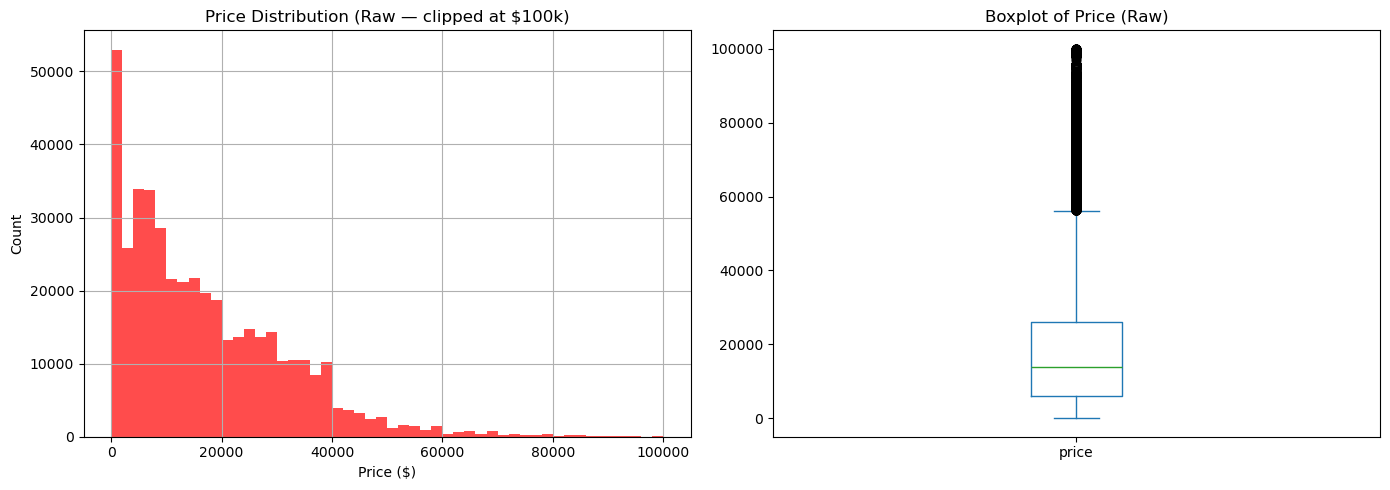

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['price'] < 100000]['price'].hist(bins=50, ax=axes[0], color='red', alpha=0.7)
axes[0].set_title('Price Distribution (Raw — clipped at $100k)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

df[df['price'] < 100000]['price'].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplot of Price (Raw)')

plt.tight_layout()
plt.show()

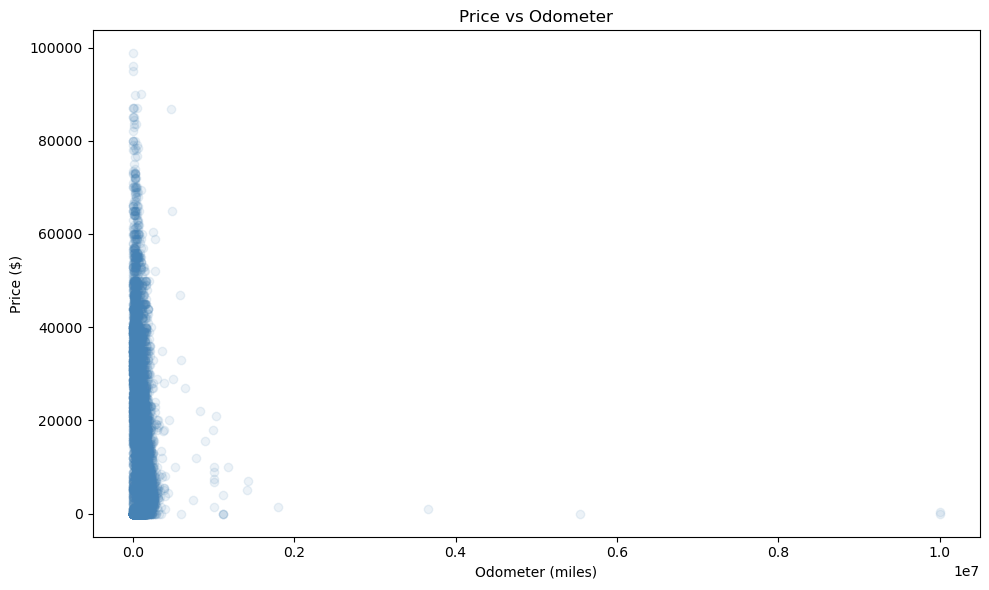

In [10]:
plt.figure(figsize=(10, 6))
sample = df[(df['price'] < 100000) & (df['odometer'].notna())].sample(10000, random_state=42)
plt.scatter(sample['odometer'], sample['price'], alpha=0.1, color='steelblue')
plt.title('Price vs Odometer')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

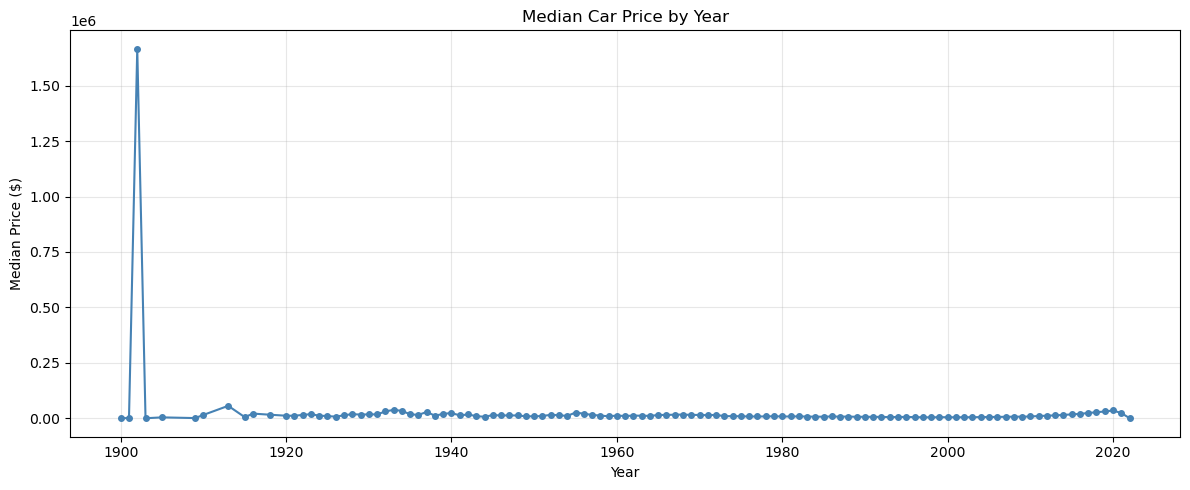

In [11]:
plt.figure(figsize=(12, 5))
df[df['year'].notna()].groupby('year')['price'].median().plot(
    kind='line', color='steelblue', marker='o', markersize=4)
plt.title('Median Car Price by Year')
plt.xlabel('Year')
plt.ylabel('Median Price ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

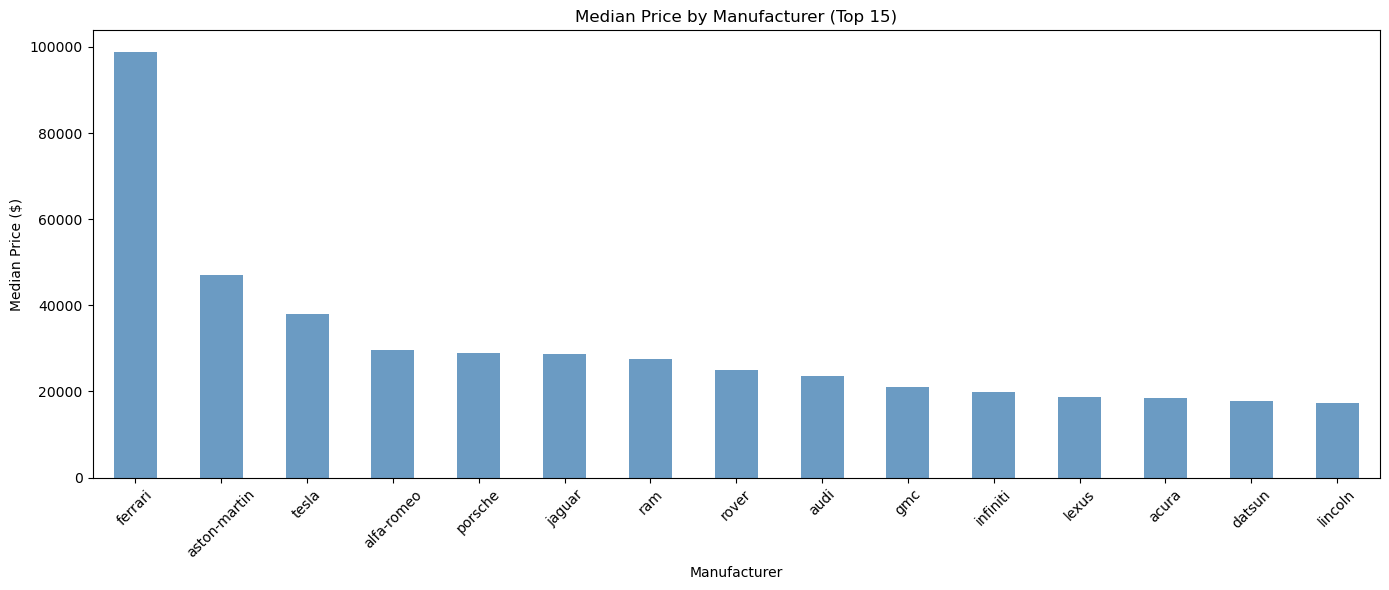

In [12]:
plt.figure(figsize=(14, 6))
top_manufacturers = df.groupby('manufacturer')['price'].median()\
                      .sort_values(ascending=False).head(15)
top_manufacturers.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Median Price by Manufacturer (Top 15)')
plt.xlabel('Manufacturer')
plt.ylabel('Median Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
df = df[(df['price'] >= 500) & (df['price'] <= 100000)]

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f'Q1: ${Q1:,.0f} | Q3: ${Q3:,.0f} | IQR: ${IQR:,.0f}')
print(f'Price bounds: [${lower:,.0f} — ${upper:,.0f}]')

df = df[(df['price'] >= lower) & (df['price'] <= upper)]
print(f'\nDataset after outlier removal: {df.shape}')

Q1: $7,800 | Q3: $27,990 | IQR: $20,190
Price bounds: [$-22,485 — $58,275]

Dataset after outlier removal: (377002, 26)


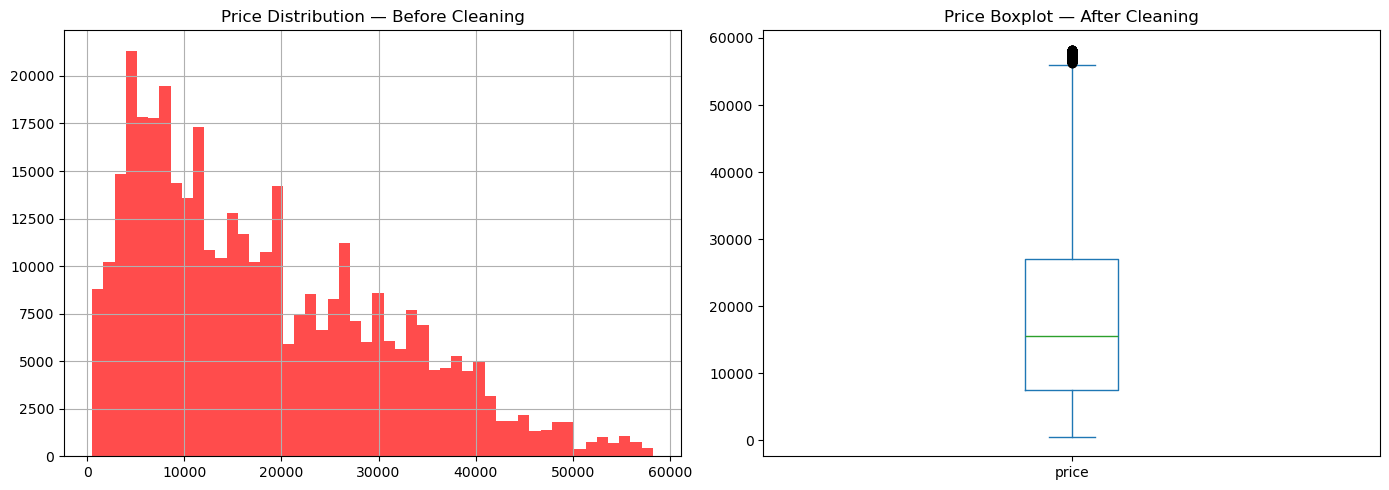

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('Price Distribution — Before Cleaning')
df['price'].hist(bins=50, ax=axes[0], color='red', alpha=0.7)

df['price'].plot(kind='box', ax=axes[1])
axes[1].set_title('Price Boxplot — After Cleaning')

plt.tight_layout()
plt.show()

In [15]:
drop = ['id', 'url', 'region', 'region_url', 'image_url',
        'description', 'county', 'VIN', 'posting_date', 'lat', 'long', 'size']

drop = [c for c in drop if c in df.columns]
df = df.drop(columns=drop)

print(f'Remaining columns: {df.columns.tolist()}')
print(f'Shape: {df.shape}')

Remaining columns: ['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
Shape: (377002, 14)


In [16]:
cats_unknown = ['cylinders', 'condition', 'drive', 'paint_color', 'type']
for col in cats_unknown:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')

In [17]:
cat_imputer = SimpleImputer(strategy='most_frequent')
high_cats = ['manufacturer', 'model', 'title_status', 'fuel', 'transmission']
high_cats = [c for c in high_cats if c in df.columns]
df[high_cats] = cat_imputer.fit_transform(df[high_cats])

In [18]:
num_imputer = SimpleImputer(strategy='median')
df[['odometer', 'year']] = num_imputer.fit_transform(df[['odometer', 'year']])

print('Missing values after imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('No missing values remain' if df.isnull().sum().sum() == 0 else '')

Missing values after imputation:
Series([], dtype: int64)
No missing values remain


In [19]:
numerical_features   = ['year', 'odometer']
categorical_features = ['manufacturer', 'condition', 'fuel',
                        'transmission', 'drive', 'type', 'state']
categorical_features = [c for c in categorical_features if c in df.columns]

X = df[numerical_features + categorical_features]
y = df['price']

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')

Features: 9 | Samples: 377002


In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {x_train.shape} | Test: {x_test.shape}')

Train: (301601, 9) | Test: (75401, 9)


In [21]:
num_imp = SimpleImputer(strategy='median')
cat_imp = SimpleImputer(strategy='most_frequent')

In [22]:
x_train[numerical_features]   = num_imp.fit_transform(x_train[numerical_features])
x_test[numerical_features]    = num_imp.transform(x_test[numerical_features])

In [23]:
x_train[categorical_features] = cat_imp.fit_transform(x_train[categorical_features])
x_test[categorical_features]  = cat_imp.transform(x_test[categorical_features])

In [24]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_train_cat = encoder.fit_transform(x_train[categorical_features])
x_test_cat  = encoder.transform(x_test[categorical_features])

In [25]:
scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train[numerical_features])
x_test_num  = scaler.transform(x_test[numerical_features])

In [26]:
x_train_final = np.hstack([x_train_num, x_train_cat])
x_test_final  = np.hstack([x_test_num,  x_test_cat])

print(f'Final train shape: {x_train_final.shape}')
print(f'Final test shape:  {x_test_final.shape}')

Final train shape: (301601, 128)
Final test shape:  (75401, 128)


In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb

In [28]:
models = {
    'Linear Regression':  LinearRegression(),
    'Ridge':              Ridge(alpha=1.0),
    'Lasso':              Lasso(alpha=1.0),
    'KNN':                KNeighborsRegressor(n_neighbors=5),
    'Decision Tree':      DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':            xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
}

In [29]:
results = []
for name, model in models.items():
    model.fit(x_train_final, y_train)
    y_pred = model.predict(x_test_final)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append({'Model': name, 'R2': round(r2, 4), 'RMSE': round(rmse, 2)})
    print(f'{name:25s} | R²={r2:.4f} | RMSE=${rmse:,.0f}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print('\n=== Model Comparison (sorted by R²) ===')
print(results_df.to_string(index=False))

Linear Regression         | R²=0.4704 | RMSE=$9,235
Ridge                     | R²=0.4706 | RMSE=$9,234
Lasso                     | R²=0.4707 | RMSE=$9,233
KNN                       | R²=0.7873 | RMSE=$5,852
Decision Tree             | R²=0.5893 | RMSE=$8,133
Random Forest             | R²=0.8834 | RMSE=$4,334
Gradient Boosting         | R²=0.7039 | RMSE=$6,905
XGBoost                   | R²=0.7895 | RMSE=$5,822

=== Model Comparison (sorted by R²) ===
            Model     R2    RMSE
    Random Forest 0.8834 4334.01
          XGBoost 0.7895 5822.01
              KNN 0.7873 5852.37
Gradient Boosting 0.7039 6905.48
    Decision Tree 0.5893 8133.18
            Lasso 0.4707 9233.46
            Ridge 0.4706 9234.31
Linear Regression 0.4704 9235.42


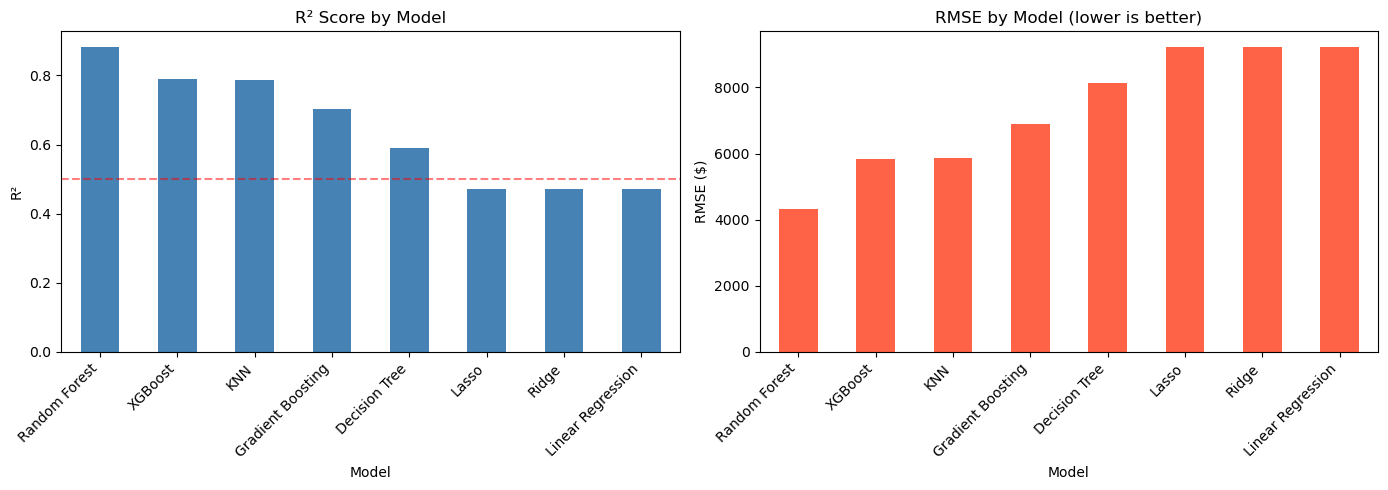

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(x='Model', y='R2', kind='bar', ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('R² Score by Model')
axes[0].set_ylabel('R²')
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='R²=0.5 baseline')

results_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[1], color='tomato', legend=False)
axes[1].set_title('RMSE by Model (lower is better)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [31]:
xgb_model2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

In [32]:
xgb_model2.fit(
    x_train_final, y_train,
    eval_set=[(x_test_final, y_test)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [33]:
y_pred2 = xgb_model2.predict(x_test_final)
rmse2   = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2    = r2_score(y_test, y_pred2)

In [34]:
print(f'R²:   {r2_2:.4f}')
print(f'RMSE: ${rmse2:,.2f}')

R²:   0.8158
RMSE: $5,446.58


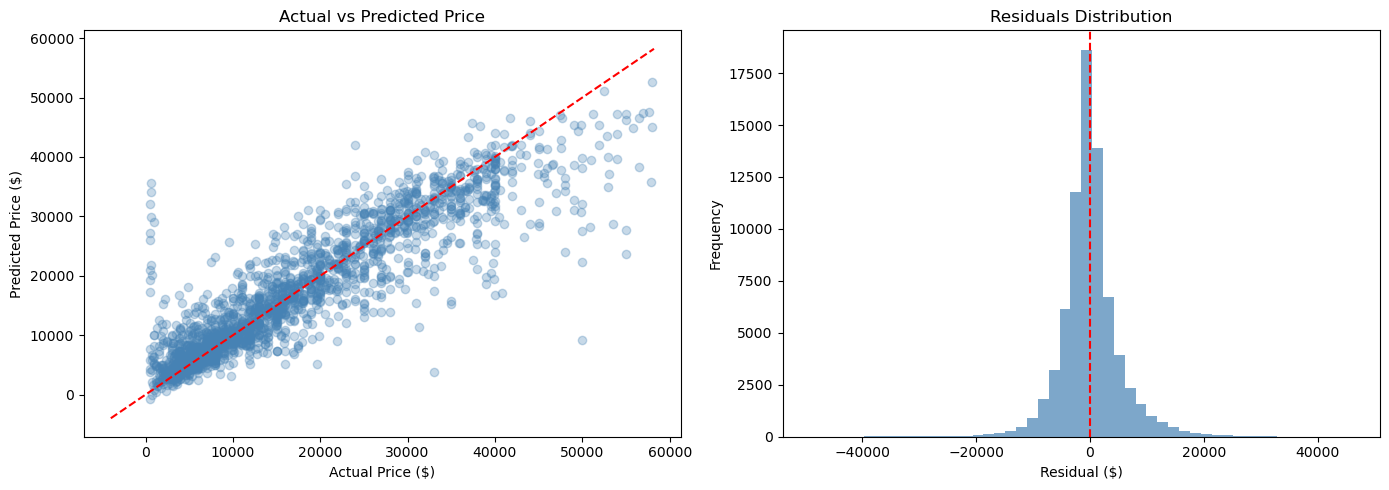

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx = np.random.choice(len(y_test), 2000, replace=False)
axes[0].scatter(np.array(y_test)[sample_idx], y_pred2[sample_idx],
                alpha=0.3, color='steelblue')
min_val = min(y_test.min(), y_pred2.min())
max_val = max(y_test.max(), y_pred2.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_title('Actual vs Predicted Price')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')

residuals = np.array(y_test) - y_pred2
axes[1].hist(residuals, bins=50, color='steelblue', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [36]:
import joblib

joblib.dump(xgb_model2,  'xgb_model.pkl')
joblib.dump(encoder,     'encoder.pkl')
joblib.dump(scaler,      'scaler.pkl')
joblib.dump(num_imp,     'num_imputer.pkl')
joblib.dump(cat_imp,     'cat_imputer.pkl')

['cat_imputer.pkl']

In [37]:
unique_values = {
    col: sorted(df[col].dropna().unique().tolist())
    for col in categorical_features
}

joblib.dump(unique_values, 'unique_values.pkl')

for col, vals in unique_values.items():
    print(f'{col}: {len(vals)} unique values')

manufacturer: 42 unique values
condition: 7 unique values
fuel: 5 unique values
transmission: 3 unique values
drive: 4 unique values
type: 14 unique values
state: 51 unique values
